# Naive Bayes Classification to Predict Titanic Survival

**Deep Dive Coding Data Science Bootcamp Sample Project**

---
Robert Citek - October 5th, 2026


## Problem Definition

State the business problem. Translate the business problem into a Data Science problem by stating what kind of problem it is ( supervised vs unsupervised ) and whether it is a classification, regression, or clustering problem.  Mention which model will be used, if known.

## Data Collection/Sources

### Data Overview

This data comes from [Kaggle](https://www.kaggle.com/c/titanic/data), which was then copied to AWS for easy access.

https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv


### Imports

In [2]:
from IPython.display import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

### File Paths

Create a variable `url` that contains the web link to the CSV data

In [9]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv'  # insert url here
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv'

### Load data

Load the data into a data frame named `titanic_df`.

In [10]:
# load data
titanic_df = pd.read_csv( url )

### head

Look at the first few rows

In [11]:
# first few rows
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### tail

Look at the last few rows


In [16]:
# last few rows
titanic_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### shape


In [15]:
# shape of data frame
titanic_df.shape  #output: display (row,column)

(891, 12)

### size


In [17]:
# size of data frame
titanic_df.size   #output: calculate the number of rows multiplied by the nuber of columns

10692

### Summary meta-data

Run the `info()` method on the data frame.


In [18]:
# display meta-data
titanic_df.info()

# display show:
#total rows= 891
#total colun=12
#non-null count= show which columns have missing data by reporting( anything less than 891)
#data type= int(whole number),float(decimal number), object(text string or mixed data)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Summary statistics

Summary statistics give you a quick overview of the data.  Some items to spot check:
- the Target:
  - look for nulls
    - null will be culled
  - look at min, max, median, and mean
    - is it a categorical field masquerading as a number?
- the Features:
  - numerical
    - look at min, max, median, and mean
      - a min=1 and max=count suggests an ID
  - categorical
    - look at unique and freq
      - freq=1, unique=count suggests an ID
      - freq=count suggests a meaningless feature

Run the `describe()` method on the data frame.

In [19]:
# display summary statistics
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### target value_counts()


The target should be the first field that you look at.  Its data type will tell you what kind of machine learning problem this is ( classification or regression. ) Any nulls should be culled.  You can check for any skew in the data set.

In [23]:
# value_counts on target ; include nulls
titanic_df['Survived'].value_counts( dropna = False )

#value_counts, count all the row but skip blank rows
#dropna = false, blank rows are counted

#output shows
#0-> passenger who died
#1-> passenger who survived, #1 usually mean yes
# since the output onluy have 2 valvues-> this is classigication

,count
Survived,
0,549
1,342


In [24]:
# normalized value_counts on target ; include nulls
titanic_df['Survived'].value_counts( normalize = True , dropna = False ) * 100

# normalize = True, take the count and divided by the total amount of rows
# ex. 549/ 891 & 342/891.


,proportion
Survived,
0,61.616162
1,38.383838


### Nulls



In [31]:
# look for nulls
titanic_df.isnull().sum()

#.isnull, this look at the table and ask if the cell blank, true of false
#.sum(), add up the column with the blanks(True)

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [33]:
# look for nulls, displaying relative frequency
null_sum = titanic_df.isnull().sum()
null_freq = null_sum / titanic_df.shape[0] *100
#.shape give (rows,columns)but [0]pick the first position(rows)
# the sum of all the null values/ number for rows
null_freq.sort_values()
#


,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000
Embarked,0.002245


### dtypes - column data types

Which data types would be appropriate for Gaussian Naive Bayes?


In [34]:
# display data types
titanic_df.info() # float and interger work best, can do math
                  # cannot use object cuz this is text. can't no math

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Unique elements


If the total number of unique items in a field equals the number of rows, that suggests those fields are unique IDs ( e.g. names, IDs ) and should be dropped.


In [42]:
# number of unique elements in a column
titanic_df.nunique(axis="rows")

# ().nunique)counts diffrent values in the column,
# (axis="rows") means it counts down each colum
# unique item, ask can this information show a pattern

# If the count = number of rows (891), every person has their own value.
# That's an ID, like PassengerId or Name. It can't show a pattern, so drop it.

# Many values isn't always bad: Age and Fare are amounts, so keep them.
# Always ask: can this column show a pattern?

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


## Data Cleaning


### Backup #1


In [48]:
# make backup
backup_titanic_df=titanic_df.copy() # .copy() makes a separate backup before cleaning
backup_titanic_df                 # this variable has the orginal 12 columns

,Survived,Age
0,0,22.0
1,1,38.0
2,1,26.0
3,1,35.0
4,0,35.0
...,...,...
886,0,27.0
887,1,19.0
888,0,NaN
889,1,26.0


In [43]:
# restore from backup
titanic_df = backup_titanic_df # this restore

### Keep only the target and one feature

Select `Survived` for the target and `Age` for the single feature

In [49]:
# select the target and one feature
titanic_df =titanic_df[['Survived','Age']] # this change this variable to hold 2 columns
titanic_df

,Survived,Age
0,0,22.0
1,1,38.0
2,1,26.0
3,1,35.0
4,0,35.0
...,...,...
886,0,27.0
887,1,19.0
888,0,NaN
889,1,26.0


### Backup #2


In [50]:
# make backup
data_cleaned_titanic_df= titanic_df.copy()  #this save the 2 column in to a new variable
data_cleaned_titanic_df # this the name of the variable with 2 columns

,Survived,Age
0,0,22.0
1,1,38.0
2,1,26.0
3,1,35.0
4,0,35.0
...,...,...
886,0,27.0
887,1,19.0
888,0,NaN
889,1,26.0


In [ ]:
# restore from backup=
titanic_df= data_cleaned_titanic_df.copy()  # this restore back to the 2 columns


### Address any rows with nulls

- If the number of nulls in a column is low, it would be easiest to drop the row.
- If the number of nulls in a column is high, it would be easiest to drop the column.
- If the number of nulls in a column is between the low and high, one should impute values for the nulls.


#### Impute

Impute with the median.


In [52]:
# Calculate the median
median_age =data_cleaned_titanic_df['Age'].median()  # this find the middle age for all passengers
median_age  #middle value, line everyone up from youngest to olderet the person in the middle

28.0

In [53]:
# Assign median to nulls
data_cleaned_titanic_df['Age'].fillna(median_age, inplace=True) # this fill any blank row under age with 28(median age)

/tmp/ipykernel_1840/3871790319.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned_titanic_df['Age'].fillna(median_age, inplace=True)


In [56]:
# Verify there are no nulls
data_cleaned_titanic_df.isnull().sum()  #this count blank cell in the column(rows)

,0
Survived,0
Age,0


In [55]:
# Verify median is about the same as before
data_cleaned_titanic_df.median()

,0
Survived,0.0
Age,28.0


## Exploratory Data Analysis


GNB has two requirements:
1. the features are normally distributed
1. the features are not correlated with each other





### normal distribution of features: histogram


<Axes: >

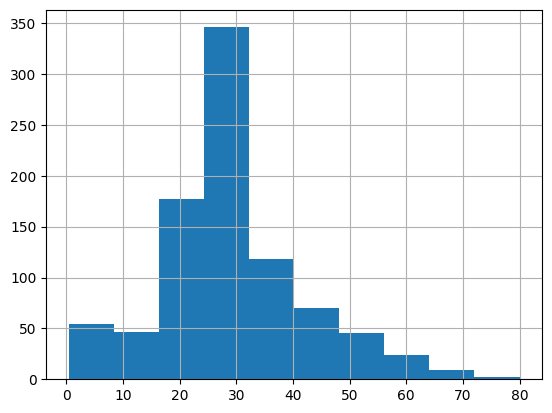

In [57]:
# Display a histogram
data_cleaned_titanic_df['Age'].hist(). # output, bar chart showing how many passengers fall into each age range

### no correlation with single feature



## Processing



In [70]:
# Split data frame into target and features
target= data_cleaned_titanic_df[['Survived']]
features = data_cleaned_titanic_df[['Age']]

In [71]:
# Verify features
features

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


In [67]:
# Verify target
target

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


### Single Cross Validation ( CV )

Run a single Cross Validation

#### Train Test Split

In [73]:
# Train Test Split
x_train, x_test, y_train, y_test= train_test_split(features,target, test_size=0.25)

#train_test_split only work if you import (from sklearn.model_selection import train_test_split )

# x=features(clues)
# y= target(answers)

# x_train= age for the training group
# x_test= age of the test group
# y_train= survived answer for the training group
# y_test= survived answers for the test group

In [74]:
# Verify shape of each data set from Train Test Split
for i in (x_train, x_test, y_train, y_test):
  print(i.shape)

#668 + 223 = 891. Nobody got lost. ✓
#223 ÷ 891 ≈ 25%, matching test_size=0.25. ✓


(668, 1)
(223, 1)
(668, 1)
(223, 1)


#### Model


In [75]:
# Create an empty GNB model
modelGNB = GaussianNB()

#### Fit



In [76]:
# Train ( fit ) the model
modelGNB.fit(pd.DataFrame (x_train), y_train)

#.fit(...) → “learn from this data.” This is the training step.
#x_train → the ages of the 668 training passengers.
#y_train → whether each of them survived.

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

#### Prediction


In [78]:
# Make predicitons using the model
pred_results =modelGNB.predict(pd.DataFrame(x_test))
pred_results

#.predict(...) → “make guesses.” The model looks at each age and decides 0 or 1.
#x_test → the 223 ages it has never seen.

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0])

#### Performance


We'll meassure accuracy, which is the proportions of the number correctly predicted, which is mathematically the same as one minus the proportion incorrectly predicted.

In [79]:
# Calculate the accuracy
accuracy =metrics.accuracy_score(y_test,pred_results)
accuracy*100

#.accuracy_score(y_test, pred_results) → compares the real answers with the model’s guesses, one passenger at a time, and returns the share it got right

64.57399103139014

Text(113.9222222222222, 0.5, 'Predicted')

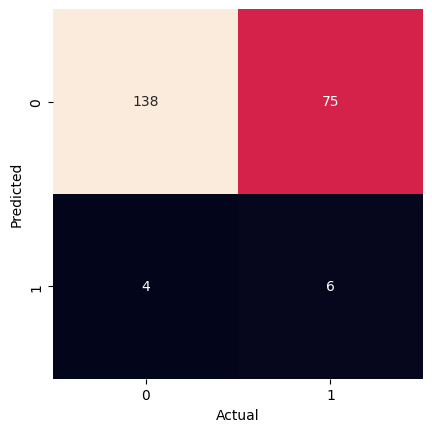

In [91]:
# Display a confusion matrix

# EXTRA: chart size (turned off)
#plt.figure(figsize=(8,8))

# NEEDED: count right and wrong guesses
mat = metrics.confusion_matrix(y_test, pred_results)

# NEEDED: draw the grid
sns.heatmap(mat.T,      # EXTRA: .T flips the grid
    square=True,        # EXTRA: square boxes
    annot=True,         # NEEDED: show numbers
    fmt='d',            # NEEDED: whole numbers
    cbar=False,         # EXTRA: hide color bar

)

# EXTRA: label the sides
plt.xlabel('Actual')
plt.ylabel('Predicted')


#output	R
#Right guesses
#138 → The model said “died.” They did die. ✓
#6 → The model said “lived.” They did live. ✓

#Wrong guesses
#75 → The model said “died.” But they lived. ✗
#4 → The model said “lived.” But they died. ✗

### Multiple Cross Validation ( CV )

Create a CV loop with 100 iterations.  Capture performance metric in an array names `results`.
Use accuracy for the performance metric.


In [97]:
# Multiple CV loop
results =[]  #make an empty list for the score
for i in range(100): #repeat 100 times
  x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.25) #new  random split each time
  modelGNB = GaussianNB() #new empty model
  modelGNB.fit(pd.DataFrame (x_train), y_train) # train it
  pred_results =modelGNB.predict(pd.DataFrame(x_test)) #predicts
  accuracy = metrics.accuracy_score(y_test, pred_results) #score it
  results.append(accuracy) #save the score
results = np.array(results)
results #show all 100 scores




/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

array([0.64573991, 0.60986547, 0.6367713 , 0.65470852, 0.59192825,
       0.64125561, 0.59641256, 0.61883408, 0.65470852, 0.66367713,
       0.64125561, 0.62780269, 0.632287  , 0.61434978, 0.65022422,
       0.58295964, 0.64573991, 0.58744395, 0.62780269, 0.59192825,
       0.632287  , 0.62331839, 0.58295964, 0.65022422, 0.64125561,
       0.62331839, 0.61883408, 0.65470852, 0.62331839, 0.59192825,
       0.59192825, 0.68609865, 0.68161435, 0.58744395, 0.66367713,
       0.61434978, 0.6367713 , 0.60089686, 0.66367713, 0.62780269,
       0.632287  , 0.61434978, 0.6367713 , 0.60089686, 0.64125561,
       0.60089686, 0.65919283, 0.66367713, 0.69506726, 0.60089686,
       0.62331839, 0.59192825, 0.61883408, 0.61434978, 0.64573991,
       0.66816143, 0.61434978, 0.60089686, 0.56053812, 0.60538117,
       0.58744395, 0.64573991, 0.62331839, 0.65022422, 0.61883408,
       0.62331839, 0.60538117, 0.62780269, 0.62331839, 0.58295964,
       0.61883408, 0.64573991, 0.60538117, 0.65919283, 0.62331

In [98]:
# Calculate mean of results
results.mean()

np.float64(0.6244843049327354)

<Axes: >

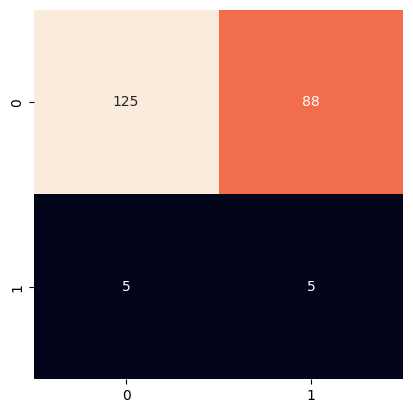

In [100]:
# Display a confusion matrix
mat = metrics.confusion_matrix(y_test, pred_results)
sns.heatmap(mat.T,      # EXTRA: .T flips the grid
    square=True,        # EXTRA: square boxes
    annot=True,         # NEEDED: show numbers
    fmt='d',            # NEEDED: whole numbers
    cbar=False,
)

(array([ 2.,  5., 14., 12., 22., 14., 13., 12.,  3.,  3.]),
 array([0.56053812, 0.57399103, 0.58744395, 0.60089686, 0.61434978,
        0.62780269, 0.64125561, 0.65470852, 0.66816143, 0.68161435,
        0.69506726]),
 <BarContainer object of 10 artists>)

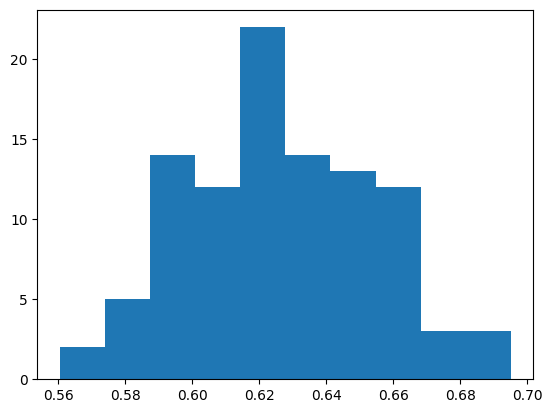

In [101]:
# Display a histogram of the results
plt.hist(results)

## Communication of Results

Conclusion:

Future work:

